## Data Preprocessing

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

In [47]:
data = pd.read_csv('METABRIC_RNA_Mutation.csv')

/var/folders/9s/lmflxdbd45vd7h4ltzm2694m0000gn/T/ipykernel_16409/1373502466.py:1: DtypeWarning: Columns (678,688,690,692) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('METABRIC_RNA_Mutation.csv')


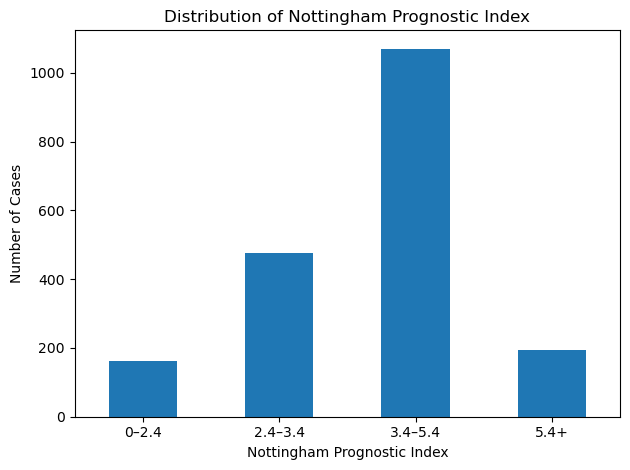

In [48]:
# Visualize NPI Data into four bins
npi = data['nottingham_prognostic_index']

bins = [0, 2.4, 3.4, 5.4, np.inf]
labels = ['0–2.4', '2.4–3.4', '3.4–5.4', '5.4+']

categories = pd.cut(npi, bins=bins, labels=labels, right=False)
counts = categories.value_counts().sort_index()

# Plot
plt.figure()
counts.plot(kind='bar')
plt.xlabel('Nottingham Prognostic Index')
plt.ylabel('Number of Cases')
plt.title('Distribution of Nottingham Prognostic Index')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
target = 'nottingham_prognostic_index'
X = data.iloc[:, -662:] # all gene expression data

#X = data.iloc[:, -662:-173] # gene expression excl. mutation
y = data[target]

In [50]:
# FOR decision tree
# Convert all mutation columns to boolean (0 if 0, 1 if otherwise)
invalid = X.select_dtypes(exclude=['number','bool','category']).columns.tolist()
for c in invalid:
    X[c] = (X[c] != "0").astype(int)

In [51]:
# Further normalization, not needed for decision tree
#scaler = MinMaxScaler(feature_range=(0, 1))
#num_cols = X.select_dtypes(include='number').columns
#X[num_cols] = scaler.fit_transform(X[num_cols])

In [52]:
# Split the NPI into four classes
#bins   = [0, 2.4, 3.4, 5.4, np.inf]
#labels = [0, 1, 2, 3]

# Split the NPI into two classes
bins   = [0, 3.4, np.inf]
labels = [0, 1]

y_binned = pd.cut(y, bins=bins, labels=labels)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binned, test_size=0.2, random_state=42, stratify=y_binned
)

# Helper Functions

In [53]:
# Function for Evaluation
def evaluate(y_test, y_pred, labels={0: 'NPI≤3.4', 1: 'NPI>3.4'}):
    # Classification Report
    accracy = accuracy_score(y_test, y_pred)
    print(f'Classifiction accuracy: {accracy:.2f}')
    print('\nClassification report:')
    print(classification_report(y_test, y_pred,
                            target_names=[labels[0], labels[1]]))


    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=[labels[0], labels[1]])
    fig, ax = plt.subplots(figsize=(5,5))
    disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
    plt.title('Confusion Matrix (Test Set)')
    plt.tight_layout()
    plt.show()


# Handle class imbalance
def compute_sample_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight('balanced', classes=classes, y=y)
    return dict(zip(classes, weights))

# Lightgbm (single fit)

In [54]:
# Handle class imbalance
def compute_sample_weights(y_cls):
    classes = np.unique(y_cls)
    class_weights = compute_class_weight('balanced', classes=classes, y=y_cls)
    weight_map = dict(zip(classes, class_weights))
    return np.array([weight_map[c] for c in y_cls])

# Train
def train_lightgbm_classifier(X_train, y_train_cls, sample_weight=None, params=None):
    if params is None:
        params = {
            'objective': 'multiclass',
            'num_class': 2,
            'metric': 'multi_logloss',
            'verbosity': -1,
            'random_state': 42,
            'num_leaves': 100,
            'max_depth': 10,
            'learning_rate': 0.03,
            'subsample': 0.8,
            'feature_fraction': 0.8,
        }
    clf = lgb.LGBMClassifier(**params)
    clf.fit(X_train, y_train_cls, sample_weight=sample_weight)
    return clf


Classifiction accuracy: 0.72

Classification report:
              precision    recall  f1-score   support

     NPI≤3.4       0.60      0.56      0.58       128
     NPI>3.4       0.78      0.81      0.80       253

    accuracy                           0.72       381
   macro avg       0.69      0.68      0.69       381
weighted avg       0.72      0.72      0.72       381



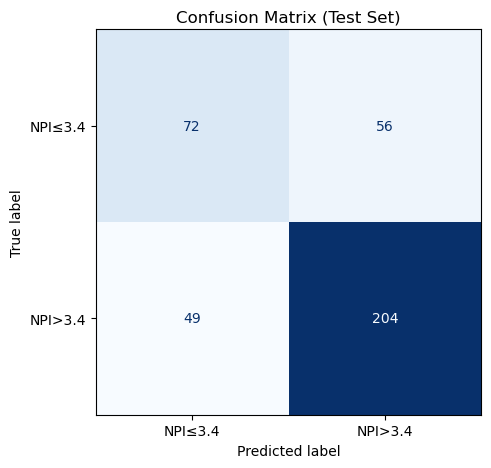

In [55]:
# compute sample weights to handle class imbalance
sample_weights = compute_sample_weights(y_train)

# train classifier
clf = train_lightgbm_classifier(X_train, y_train, sample_weight=sample_weights)

#y_train_predicted = clf.predict(X_train)
#evaluate(y_train, y_train_predicted)

# evaluate on held‐out test set
y_pred = clf.predict(X_test)
evaluate(y_test, y_pred)

# Lightgbm (hyperparam tuning)

In [44]:
# Handle imbalance
sampel_weights = np.array([compute_sample_weights(y_train)[c] for c in y_train])

# Set up pipeline
piple = Pipeline([
    ('sel', SelectKBest(mutual_info_classif)),
    ('clf', lgb.LGBMClassifier(
        objective='binary',
        random_state=42,
        n_jobs=-1
    ))
])

# Search space
pram_dist = {
    'sel__k': [100, 200, 400],
    'clf__num_leaves': [70, 127, 200],
    'clf__max_depth': [10, 20, -1],
    'clf__learning_rate': [0.01, 0.05],
    'clf__n_estimators': [100, 200],
    'clf__subsample': [0.6, 0.8],
    'clf__colsample_bytree': [0.6, 0.8],
    'clf__reg_alpha': [0.1],
    'clf__reg_lambda': [0.1],
}

# Search with cross valiadtion
cvf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=piple,
    param_distributions=pram_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=cvf,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

search.fit(
    X_train, y_train,
    clf__sample_weight=sampel_weights
)

print("Best CV ROC-AUC:", search.best_score_)
print("Best hyper-parameters:", search.best_params_)

[LightGBM] [Info] Number of positive: 808, number of negative: 410
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003511 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51000
[LightGBM] [Info] Number of data points in the train set: 1218, number of used features: 200
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499509 -> initscore=-0.001966
[LightGBM] [Info] Start training from score -0.001966
[LightGBM] [Info] Number of positive: 809, number of negative: 410
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51000
[LightGBM] [Info] Number of data points in the train set: 1219, number of used features: 200
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499818 -> initscore=-0.000729
[LightGBM] [Info] Start training from score -0.000729
[LightGBM] [Info] 

Classifiction accuracy: 0.69

Classification report:
              precision    recall  f1-score   support

     NPI≤3.4       0.54      0.59      0.56       128
     NPI>3.4       0.78      0.74      0.76       253

    accuracy                           0.69       381
   macro avg       0.66      0.66      0.66       381
weighted avg       0.70      0.69      0.69       381



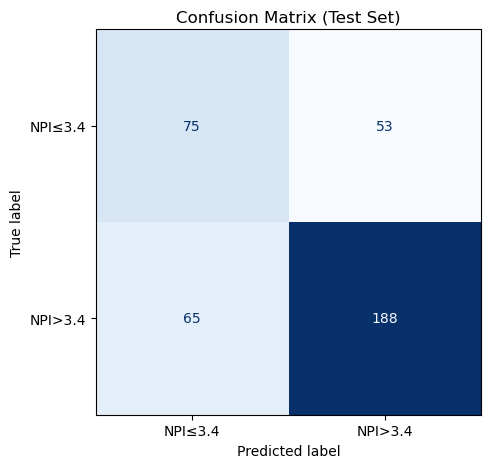

In [45]:
# Evaluate on test dataset
best_piple = search.best_estimator_
y_pred     = best_piple.predict(X_test)
evaluate(y_test, y_pred)

# Dimentionality reduction

In [19]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Params
colors = {0: 'blue', 1: 'red'}
labels = {0: 'NPI≤3.4', 1: 'NPI>3.4'}

/var/folders/9s/lmflxdbd45vd7h4ltzm2694m0000gn/T/ipykernel_16409/287467970.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


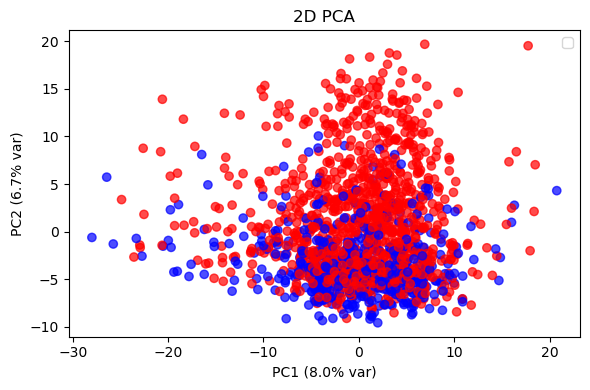

In [42]:
from sklearn.decomposition import PCA

# Fit PCA (2 components)
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

# Plot the two principal components
plt.figure(figsize=(6, 4))
colors = {0: 'blue', 1: 'red'}
plt.scatter(
    X_train_pca[:, 0], 
    X_train_pca[:, 1], 
    c=[colors[int(label)] for label in y_train],
    alpha=0.7
)

plt.xlabel('PC1 (%.1f%% var)' % (100 * pca.explained_variance_ratio_[0]))
plt.ylabel('PC2 (%.1f%% var)' % (100 * pca.explained_variance_ratio_[1]))
plt.title('2D PCA')
plt.legend()
plt.tight_layout()
plt.show()

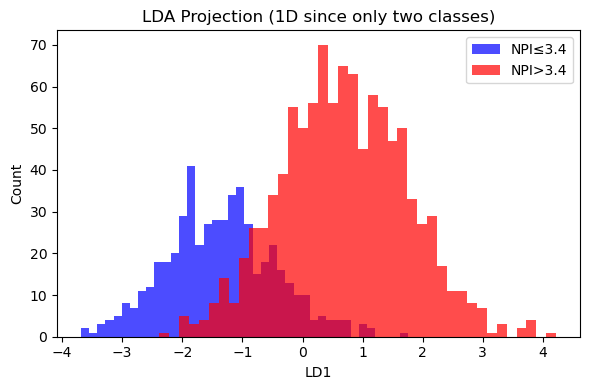

In [39]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Fit LDA (max 1 component, cannot be 2D since only 2 classes)
lda = LinearDiscriminantAnalysis(n_components=1)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)

# Plot
plt.figure(figsize=(6, 4))
for cls in [0, 1]:
    plt.hist(
        X_train_lda[y_train == cls].ravel(), 
        bins=40, 
        alpha=0.7, 
        color=colors[cls], 
        label=labels[cls]
    )

plt.xlabel('LD1')
plt.ylabel('Count')
plt.title('LDA Projection (1D since only two classes)')
plt.legend()
plt.tight_layout()
plt.show()

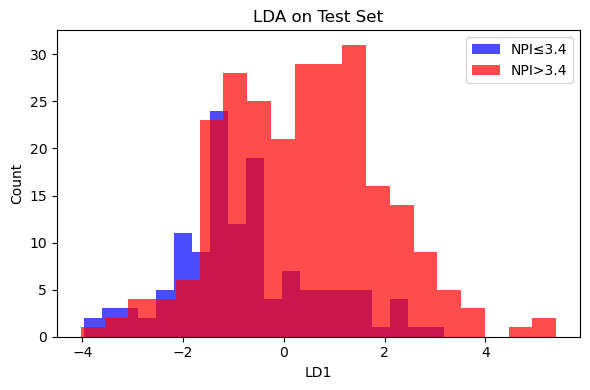

Classifiction accuracy: 0.69

Classification report:
              precision    recall  f1-score   support

     NPI≤3.4       0.53      0.62      0.57       128
     NPI>3.4       0.79      0.72      0.75       253

    accuracy                           0.69       381
   macro avg       0.66      0.67      0.66       381
weighted avg       0.70      0.69      0.69       381



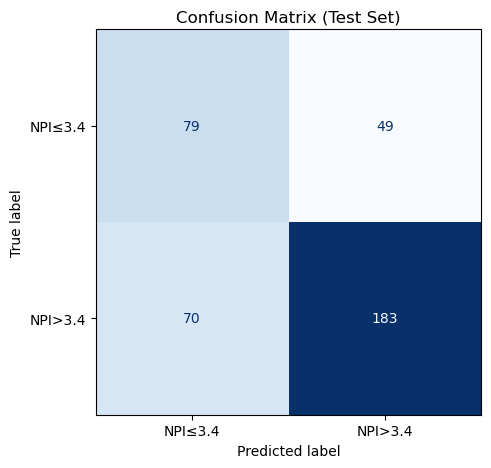

In [40]:
# Scale & project test set
X_test_scaled = scaler.transform(X_test)
X_test_lda    = lda.transform(X_test_scaled)  # shape = (n_samples_test, 1)

# Fit LDA on test data
plt.figure(figsize=(6, 4))
for cls in [0, 1]:
    plt.hist(
        X_test_lda[y_test == cls].ravel(),
        bins=20,
        alpha=0.7,
        color=colors[cls],
        label=labels[cls]
    )
plt.xlabel('LD1')
plt.ylabel('Count')
plt.title('LDA on Test Set')
plt.legend()
plt.tight_layout()
plt.show()

# Classify and compute metrics
y_pred = lda.predict(X_test_scaled)
evaluate(y_test, y_pred)

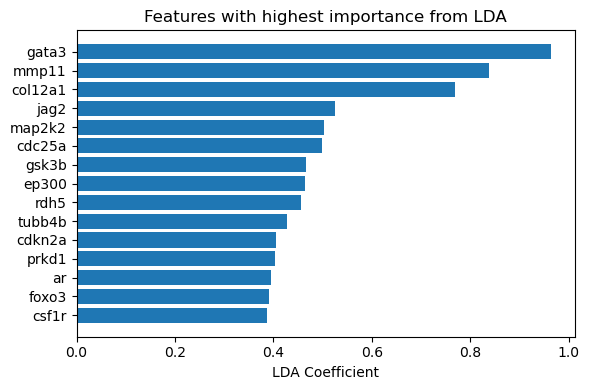

In [43]:
# Feature Importance from LDA

coef = lda.coef_[0]
feature_names = list(X_train.columns)

# Pick top 15
importances = np.abs(coef)
indices = np.argsort(importances)[::-1][:15]
top_featuress = [feature_names[i] for i in indices]
top_importancs  = importances[indices]

# Plot
plt.figure(figsize=(6, 4))
plt.barh(top_featuress[::-1],     # reverse so the largest is at the top
         top_importancs[::-1])
plt.xlabel('LDA Coefficient')
plt.title('Features with highest importance from LDA')
plt.tight_layout()
plt.show()